# Model-Free Learning: Tabular Methods
In this notebook, we explore model-free **LEARNING** algorithms, whose goal is learning or predicting the value function $ V(s) $ for a given policy $ \pi(s) $. Unlike Dynamic Programming (DP), model-free methods do not require knowledge of the model of the environment ($p(s', r | s, a)$). Instead, they learn from raw experience by interacting with the environment directly.

In [1]:
#import sys
#import os
#sys.path.append(os.path.abspath('..'))  # Allow importing from parent directory

import time
from IPython.display import display, clear_output
from envs.maze_env import MazeEnv, UP, DOWN, LEFT, RIGHT
from algorithms.policy_evaluation import BaseMazeDPAlgorithm
from algorithms.monte_carlo_evaluation import MonteCarloPrediction
from algorithms.td_evaluation import TDPrediction, TDLambdaPrediction
from utils.visualization import plot_grid, plot_policy

## 1. Environment Setup
Let's set up our standard Maze environment layout.

In [2]:
# 1. Setup the Maze layout
maze_layout = [
    ['S', '.', '.', '.', '.', 'X'],
    ['.', 'X', 'X', '.', '.', 'X'],
    ['.', '.', 'X', 'X', '.', '.'],
    ['.', 'X', 'X', 'X', 'X', '.'],
    ['.', '.', '.', '.', '.', 'G'],
]

# 2. Define the reward function
REWARD_STEP = -1.0
REWARD_GOAL = 20.0
REWARD_WALL = -0.25

# Initialize the Maze
env = MazeEnv(maze_layout=maze_layout, 
            reward_step=REWARD_STEP, 
            reward_goal=REWARD_GOAL, 
            reward_wall=REWARD_WALL)

# 3. Define discount factor
GAMMA = 0.90

## 2. Defining a Policy for Evaluation
In model-free prediction, we evaluate a given policy. We can define a policy as a mapping from states to action probabilities. Here we define a specific policy $\pi$ that can be changed to any other policy.

In [3]:
# Create a stochastic policy
my_policy = {}
for r in range(env.height):
    for c in range(env.width):
        if env.maze[r][c] not in ['G', 'X']:
            if r == 0:
                # top row (NB: row probabilities across actions must sum to 1)
                my_policy[(r, c)] = {UP: 0.0, DOWN: 0.10, LEFT: 0.55, RIGHT: 0.35}
            elif r==1:
                # second row
                my_policy[(r, c)] = {UP: 0.2, DOWN: 0.15, LEFT: 0.3, RIGHT: 0.35}
            else:
                my_policy[(r, c)] = {
                UP: 0.25,
                DOWN: 0.25,
                LEFT: 0.25,
                RIGHT: 0.25
            }

Once we define our policy, we are first going to evaluate it via Dynamic Programming algorithms, assuming we have perfect knowledge of the environment (transition probabilities and rewards). We will use this perfect evaluation as a benchmark to compare our model-free algorithms against.

In [4]:
# Evaluate the Policy via DP
evaluator = BaseMazeDPAlgorithm(env, gamma=GAMMA)
true_V = evaluator.evaluate_policy(my_policy, return_history=False, verbose=False)

Policy evaluation converged after 105 iterations. Time taken: 0.0055 seconds


## 3. Monte Carlo Prediction
The first algorithm we will implement is Monte Carlo Prediction, which is a model-free algorithm that learns the value function $ V(s) $ by following the policy and generating multiple episodes. At the end of each episode, the algorithm updates the value function across each state it visited, by using the total return ($ G $) of the episode calculated from that specific state onwards.

In [10]:
# Defining the number of episodes for MC evaluation
max_episodes = 2500

mc_prediction = MonteCarloPrediction(env, gamma=GAMMA)
V_mc = mc_prediction.evaluate_policy(
                            policy=my_policy,
                            num_episodes=max_episodes,
                            max_steps=250,
                            first_visit=True,   # this indicates we are using first-visit MC
                            verbose=True,
                            true_v=true_V,
                        )

# Storing locally the history of some relevant episodes which can be replayed later
first_episode = mc_prediction.history_ep1.copy()
second_episode = mc_prediction.history_ep2.copy()
third_episode = mc_prediction.history_ep3.copy()
first_success = mc_prediction.history_first_success.copy()

Monte Carlo prediction completed 2500 episodes in 1.0963 seconds.
Goal reached 1234 times (49.36%).


### 3.1 Monte Carlo Prediction - Episode by episode updates
We saved and stored some variables representing the full history for some specific episodes. The history of one episode includes the collection of all state-action-reward pairs that the agent has done during that single episode. This set of information is used by the algorithm to update the value function state by state. Notice that if we are using first-visit MC, for each episode we will have only one update for each state reached by the agent. That would change if we used every-time visit MC. The following lines of code will show interactively and step by step how the value function $ V(s) $ is updated during each stored episode.

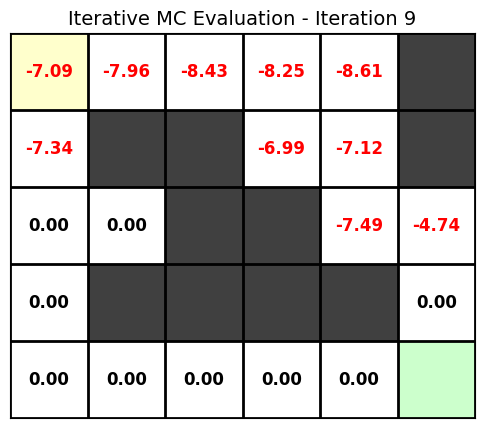

In [11]:
# Iterate through the history and animate
step_size = 1   # for every-time visit MC suggestion is to use a step size > 1
algorithm_name = "MC Evaluation"
CURR_EPISODE = first_episode    # second_episode, ... , first_success

for i in range(0, len(CURR_EPISODE), step_size):

    clear_output(wait=True)  # This deletes the previous plot before showing the new one
    plot_grid(env, algorithm_name, CURR_EPISODE[i], i)
    time.sleep(2)   # change this param to increase / decrease the speed of updates.

### 3.2 Monte Carlo Prediction - RMSE across episodes

Having calculated earlier our true value function $ V(s) $ allows us to compare it to the value function obtained after each episode by the algorithm and show the rate of convergence along as the precision of the algorithm episode by episode.

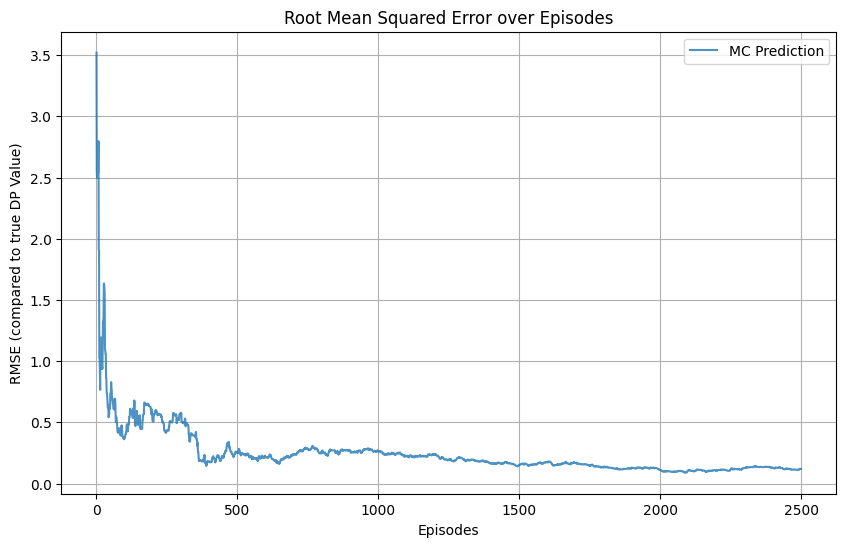

In [12]:
import matplotlib.pyplot as plt

# Extract the recorded errors
mc_errors = mc_prediction.errors

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_episodes + 1), mc_errors, label="MC Prediction", alpha=0.8)
plt.title("Root Mean Squared Error over Episodes")
plt.xlabel("Episodes")
plt.ylabel("RMSE (compared to true DP Value)")
plt.legend()
plt.grid(True)
plt.show()

## 4. TD Learning
The second method we will test is the Temporal Difference algorithm. This algorithm still requires the agent to step into the environment and gather experience episode by episode, as in MC Learning. The difference lies in how the value function $ V(s) $ gets updated: while MC waits until the end of the episode to update each state value, TD(0) updates the value function at each step of the episode. It accomplish that by bootstrapping that is, by using the current approximation of the value function in the arrival state and the reward gathered when completing the single action. This represents a biased estimate of the future sum of rewards (because the current value function $ V(s) $ is not the correct one yet) but the "true" information gathered via the reward of that single step is enough to drive, in the limit, the whole value function towards the correct one.

In [ ]:
# Defining the number of full episodes for TD evaluation algorithm
max_episodes = 2500
ALPHA = 0.05    # alpha can be thought of as a Learning Rate

td_prediction = TDPrediction(env, gamma=GAMMA, alpha=ALPHA)   # gamma is the discount factor
V_td = td_prediction.evaluate_policy(
                            policy=my_policy,
                            num_episodes=max_episodes,
                            max_steps=250,
                            verbose=True,
                            true_v=true_V,
                        )

# Storing locally the history of some relevant episodes which can be replayed later
first_episode = td_prediction.history_ep1.copy()
second_episode = td_prediction.history_ep2.copy()
third_episode = td_prediction.history_ep3.copy()
first_success = td_prediction.history_first_success.copy()

TD(0) prediction completed 2500 episodes in 0.8361 seconds.
Goal reached 1169 times (46.76%).


### 4.1 TD Learning - Episode by Episode updates

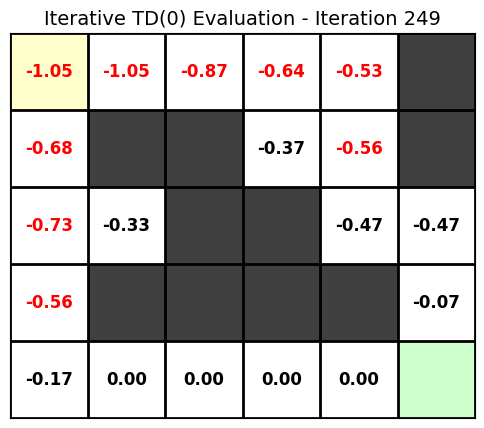

In [ ]:
# Iterate through the history and animate
step_size = 1
algorithm_name = "TD(0) Evaluation"
CURR_EPISODE = first_episode

for i in range(0, len(CURR_EPISODE), step_size):

    clear_output(wait=True)
    plot_grid(env, algorithm_name, CURR_EPISODE[i], i)
    time.sleep(1)

### 4.2 TD Learning - RMSE across episodes

Also here, by comparing the value function $ V(s) $ episode by episode against the true value function, we can get an idea regarding the the speed of convergence and precision of TD(0) algorithm.

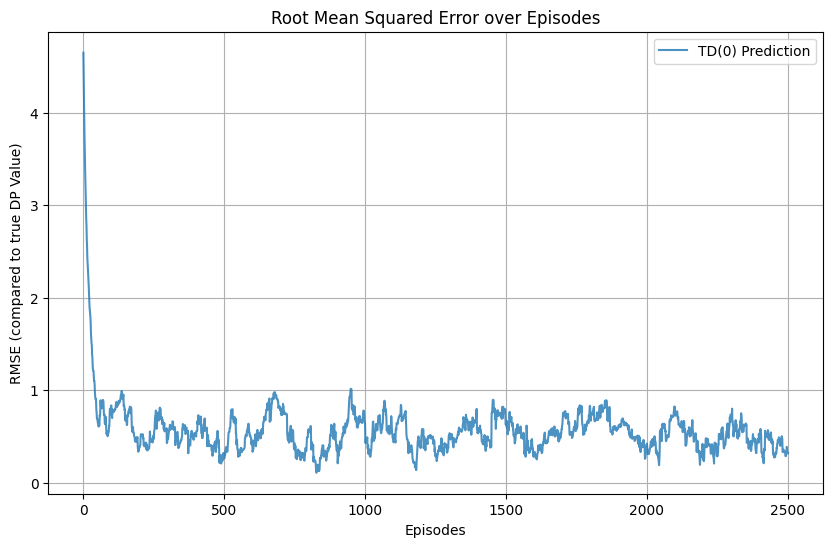

In [15]:
# Extract the recorded errors
td_errors = td_prediction.errors

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_episodes + 1), td_errors, label="TD(0) Prediction", alpha=0.8)
plt.title("Root Mean Squared Error over Episodes")
plt.xlabel("Episodes")
plt.ylabel("RMSE (compared to true DP Value)")
plt.legend()
plt.grid(True)
plt.show()

## 5. TD($ \lambda $) Learning
TD Learning or better, TD(0), is the algorithm shown above: it uses the reward gathered by taking one step ahead in the episode. What if we used 2 or 3 or 4 steps ahead instead of 1 single step? Notice that by taking infinite steps ahead we are back to MC Prediction, where we wait for the end of the episode to update the value function. TD($ \lambda $) is using a parameter - $ \lambda $ - to assign a decaying weight in a geometric fashion, to the steps ahead in our episode. The decaying weight is important because it practically truncates the look ahead period to a finite horizon. Setting lambda to 0 is equivalent to a TD(0) algorithm, setting it equal to 1 is equivalent to a MC prediction. Notice that this version TD($ \lambda $) is forward looking and to be implemented it would require an approach similar to MC prediction, that is to wait for the look ahead period - potentially infinite - before updating the current state. In order to reshape it to an online algorithm with online updates, we have implemented it the backward view version of TD($ \lambda $), which requires the introduction of eligibility traces.

In [ ]:
# Defining the number of full episodes for TD(lambda) evaluation algorithm
max_episodes = 2500
ALPHA = 0.05
LAMBDA = 0.25

td_lambda_pred = TDLambdaPrediction(env, gamma=GAMMA, alpha=ALPHA, lam=LAMBDA)
V_td = td_lambda_pred.evaluate_policy(
                        policy=my_policy,
                        num_episodes=max_episodes,
                        max_steps=250,
                        verbose=True,
                        true_v=true_V,
                        )

# Storing locally the history of some relevant episodes which can be replayed later
first_episode = td_lambda_pred.history_ep1.copy()
second_episode = td_lambda_pred.history_ep2.copy()
third_episode = td_lambda_pred.history_ep3.copy()
first_success = td_lambda_pred.history_first_success.copy()

TD(lambda) prediction completed 2500 episodes in 3.9709 seconds.
Goal reached 1221 times (48.84%).


### 5.1 TD($ \lambda $) Learning - Episode by episode updates

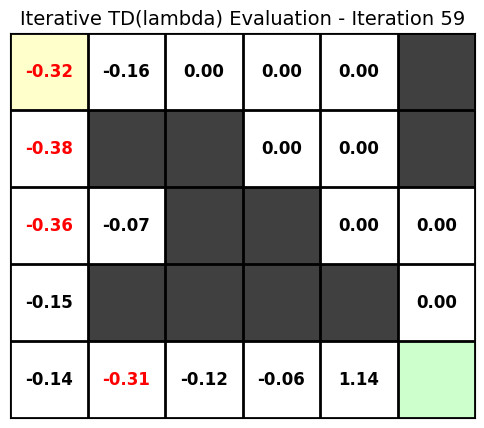

In [ ]:
# Iterate through the history and animate
step_size = 1
algorithm_name = "TD(lambda) Evaluation"
CURR_EPISODE = first_episode

for i in range(0, len(CURR_EPISODE), step_size):

    clear_output(wait=True)
    plot_grid(env, algorithm_name, CURR_EPISODE[i], i)
    time.sleep(1)

### 5.2 TD($ \lambda $) Learning - RMSE across episodes

Notice one thing looking at the RMSE both for TD(0) and TD($ \lambda $): the convergence is pretty fast but after some episodes the precision of the algorithm gets stuck at some level greater than zero and keeps oscillating there for the next episodes. This is not the case for MC Learning. The reason is technical and originates from what we defined as the *learning rate* : *alpha* . In MC Learning this rate decays naturally because each state receives more and more visits and *alpha* is defined there as the frequency of visits to the states, which vanishes in the limit. Instead, for TD algorithms we used a fixed learning rate (hence not decaying). In particular, the sequence of learning rates *alpha*_t shoud satisfy the Robbinson-Monroe conditions, coming from stochastic approximation theory, for the value function of the algorithm to effectively converge to the true value function. These conditions are automatically satisfied for MC Learning, but not for constant learning rate used in TD Learning.

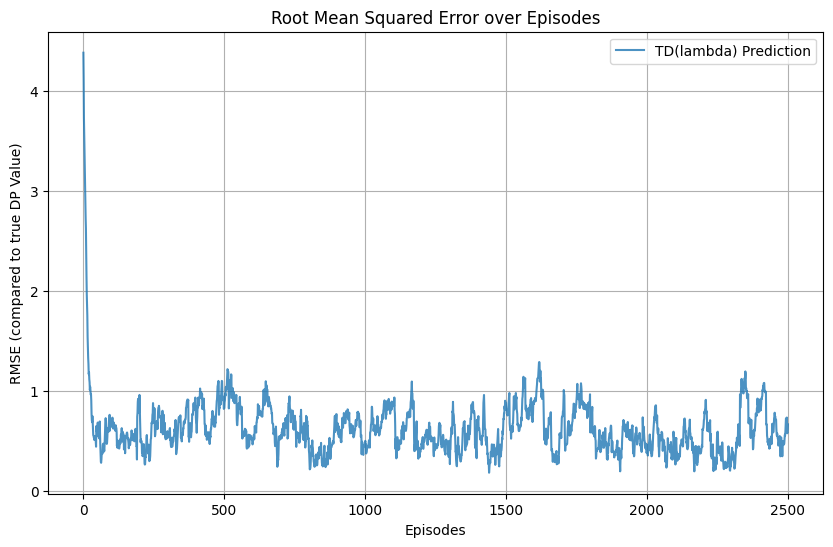

In [20]:
# Extract the recorded errors
td_errors = td_lambda_pred.errors

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_episodes + 1), td_errors, label="TD(lambda) Prediction", alpha=0.8)
plt.title("Root Mean Squared Error over Episodes")
plt.xlabel("Episodes")
plt.ylabel("RMSE (compared to true DP Value)")
plt.legend()
plt.grid(True)
plt.show()